In [1]:
 # importing important libraries and Good setup. Ensures GPU usage and consistent numerical precision with torch.double.yield
import os
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.double
SMOKE_TEST = os.environ.get("SMOKE_TEST")

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patches as patches

In [ ]:
#Code for Figure 1B
def plot_search_space():
    """
    Plot the search space as a function of the number of variables.
    """
    size_1 = 15
    size_2 = 18

    # Define the number of variables and corresponding deltas and precisions
    x = [1, 2, 3, 4, 5, 6, 7, 8, 9]
    delta = [65, 0.05, 0.8, 0.75, 0.4, 0.4, 5, 2.13, 0.4]
    percision = [13, 0.01, 0.16, 0.15, 0.08, 0.08, 1, 0.426, 0.08]
    result = [round(d / p) for d, p in zip(delta, percision)]

    # Calculate the cumulative product to represent the search space
    result_new = []
    product = 1
    for value in result:
        product *= value
        result_new.append(product)

    # Plotting
    plt.figure(figsize=(8, 8))
    plt.scatter(x, result_new, color='black', s=200)
    plt.plot(x, result_new, color='black', linewidth=2)
    plt.yscale('log')

    # Labels and formatting
    plt.xlabel("Number of variables", fontsize=size_2)
    plt.ylabel("Number of points (search space)", fontsize=size_2)
    plt.xlim([0, x[-1]*1.05])
    plt.ylim([0, result_new[-1]*10])

    # Style adjustments
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=size_1)
    ax.tick_params(axis='y', labelsize=size_1)

    # Save and display the plot
    plt.savefig('Search_space.png', dpi=1000, bbox_inches='tight')
    plt.show()

/tmp/ipython-input-3-664453508.py:31: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim([0, result_new[-1]*10])


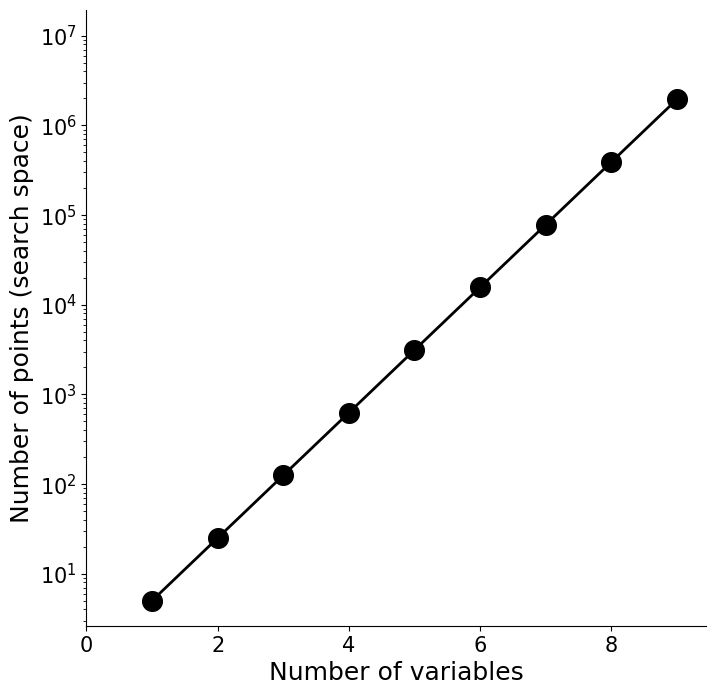

In [ ]:
plot_search_space()

In [6]:
#Code for Figure 2A
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_hydrogen_concentration_vs_experiment_number():
    size_1 = 20
    size_2 = 25

    from google.colab import drive
    drive.mount('/content/drive')

    file_path = '/content/drive/My Drive/Abate_Post_Doc/Bayesian_optimization_Tim/Addis_Ammonia/SHAP/Full_Data_Synthetic.csv'
    data = pd.read_csv(file_path)

    x = data['Expemt #']
    y = data['H2']
    types = data['Type']

    _labels = {
        'Initialization': 'Initialization (INIT)',
        'Optimization': 'Bayesian Optimization (BO)',
        'ChatGPT': 'ChatGPT',
        'Human in loop': 'Human in Loop (HIL)'
    }

    plt.figure(figsize=(11, 8))
    ax = plt.gca()

    # 3. Add dotted lines between phase changes (based on type transitions)
    start_idx = 0
    for i in range(1, len(types)):
        if types.iloc[i] != types.iloc[i-1]:
            plt.axvline(x=x.iloc[i] - 0.5, color='gray', linestyle='--', linewidth=1)
            start_idx = i

    # 4. Scatter points
    color_map = {
        'Initialization': 'white',
        'Optimization': 'grey',
        'ChatGPT': 'orange',
        'Human in loop': 'cyan'
    }
    for label, color in color_map.items():
        subset = data[types == label]
        plt.scatter(subset['Expemt #'], subset['H2'],
                    s=200, facecolors=color, edgecolors='black',
                    linewidths=1.5, label=_labels[label], zorder=3)

    # 5. Connect selected points with orange lines
    points_to_connect = [1, 4, 6, 8, 9, 11, 49, 51, 60, 86, 87]
    for i in range(len(points_to_connect) - 1):
        start = points_to_connect[i]
        end = points_to_connect[i + 1]
        y_start = y[x == start].values[0]
        y_end = y[x == end].values[0]
        plt.plot([start, end], [y_start, y_start], color='orange', linestyle='-', linewidth=4.5)
        if y_start != y_end:
            plt.plot([end, end], [y_start, y_end], color='orange', linestyle='-', linewidth=4.5)
    last_point = points_to_connect[-1]
    y_last = y[x == last_point].values[0]
    plt.plot([last_point, x.max()], [y_last, y_last], color='orange', linestyle='-', linewidth=4.5)

    # Shade background regions for each phase (individually for each block)
    prev_type = types.iloc[0]
    start_exp = x.iloc[0]

    for i in range(1, len(types)):
       curr_type = types.iloc[i]
       if curr_type != prev_type:
         end_exp = x.iloc[i - 1] + 0.5  # end of previous block
         start_shade = start_exp - 0.5
         color = None

         if prev_type == 'Initialization':
            color = 'white'
         elif prev_type == 'Optimization':
            color = 'lightblue'
         elif prev_type == 'ChatGPT':
            color = 'moccasin'
         elif prev_type == 'Human in loop':
            color = 'lightgreen'

         if color:
            ax.axvspan(start_shade, end_exp, color=color, alpha=0.2, zorder=0)

         start_exp = x.iloc[i]
         prev_type = curr_type

# Shade final block
    end_exp = x.iloc[-1] + 0.5
    start_shade = start_exp - 0.5
    color = None
    if prev_type == 'Initialization':
     color = 'white'
    elif prev_type == 'Optimization':
     color = 'lightblue'
    elif prev_type == 'ChatGPT':
     color = 'moccasin'
    elif prev_type == 'Human in loop':
     color = 'lightgreen'

    if color:
     ax.axvspan(start_shade, end_exp, color=color, alpha=0.2, zorder=0)

    # 6. Format axes
    plt.xlabel("Experiment number", fontsize=size_2)
    plt.ylabel("H2 (ppm)", fontsize=size_2)
    plt.xlim([0, x.max() * 1.1])
    plt.ylim([0, y.max() * 1.2])
    ax.set_yticks(np.arange(0, 40000, 6000))
    ax.tick_params(axis='x', labelsize=size_1)
    ax.tick_params(axis='y', labelsize=size_1)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)

    # 7. Annotate max H2
    max_conc = y.max()
    max_conc_exp = x[y.idxmax()]
    plt.annotate(f"Max H2 : {max_conc:.2f} ppm", (max_conc_exp, max_conc),
                 textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=size_1, color='red', fontweight='bold')

    # 8. Legend in box only
    plt.legend(fontsize=14, loc='upper left', frameon=True)

    # Show and save
    plt.tight_layout()
    plt.savefig('Concentration_plot_final.png', dpi=1000, bbox_inches='tight')
    plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


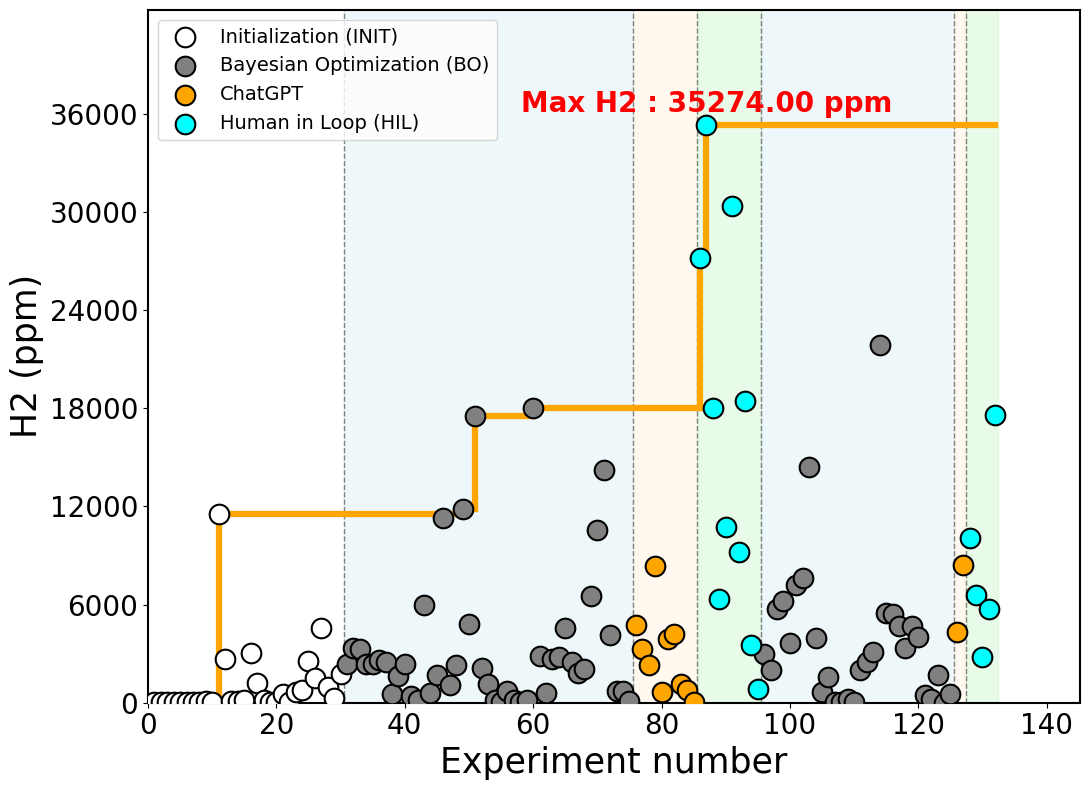

In [7]:
plot_hydrogen_concentration_vs_experiment_number()

In [1]:
#Code for Figure 2B
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd

def plot_combined_H2_parameters():
    from google.colab import drive
    drive.mount('/content/drive')

    file_path = '/content/drive/My Drive/Abate_Post_Doc/Bayesian_optimization_Tim/Addis_Ammonia/SHAP/Full_Data_Synthetic_Micromoles.csv'
    data = pd.read_csv(file_path)

    list_param = ['Temperature', 'FeCl2', 'MgCl2', 'NaOH', 'NiCl2', 'CuCl2', 'NaHCO3', 'NaCl', 'Surfactant']
    list_param_full = ['Temperature (℃)', 'FeCl2 (micromoles)', 'MgCl2 (micromoles)', 'NaOH (micromoles)', 'NiCl2 (micromoles)', 'CuCl2 (micromoles)', 'NaHCO3 (micromoles)', 'NaCl (micromoles)', 'Surfactant (micromoles)']
    panel_letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']

    color_map = {
        'Initialization': 'white',
        'Optimization': '#dbe9f6',
        'ChatGPT': '#fbead6',
        'Human in loop': '#d8f5dc'
    }

    fig, axes = plt.subplots(3, 3, figsize=(30, 34))
    axes = axes.flatten()

    for idx, input in enumerate(list_param):
        ax = axes[idx]
        x = data['Expemt #']
        y = data[input]
        color_var = data['H2']
        types = data['Type']

        # Plot scatter
        sc = ax.scatter(x, y, c=color_var, alpha=0.8, cmap='viridis', s=200)

        # Background shading
        prev_type = types.iloc[0]
        start_idx = 0
        for i in range(1, len(types)):
            if types.iloc[i] != prev_type:
                ax.axvspan(x.iloc[start_idx] - 0.5, x.iloc[i] - 0.5, color=color_map.get(prev_type, 'white'), alpha=0.3)
                start_idx = i
                prev_type = types.iloc[i]
        ax.axvspan(x.iloc[start_idx] - 0.5, x.iloc[-1] + 1, color=color_map.get(prev_type, 'white'), alpha=0.3)

        # Orange connecting lines
        points_to_connect = [1, 4, 6, 8, 9, 11, 49, 51, 60, 86, 87]
        for i in range(len(points_to_connect) - 1):
            start = points_to_connect[i]
            end = points_to_connect[i + 1]
            y_start = y[x == start].values[0]
            y_end = y[x == end].values[0]
            ax.plot([start, end], [y_start, y_start], color='orange', linewidth=8)
            if y_start != y_end:
                ax.plot([end, end], [y_start, y_end], color='orange', linewidth=8)
        last_point = points_to_connect[-1]
        y_last = y[x == last_point].values[0]
        ax.plot([last_point, x.max()], [y_last, y_last], color='orange', linewidth=8)

        # Axis and colorbar
        if idx % 3 == 2:
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.1)
            cbar = fig.colorbar(sc, cax=cax)
            cbar.set_label('H2 concentration (ppm)', fontsize=20)
            cbar.ax.tick_params(labelsize=20)

        ax.set_xlabel("Experiment number", fontsize=20 if idx >= 6 else 0)
        ax.set_ylabel(list_param_full[idx], fontsize=20)
        ax.tick_params(axis='both', labelsize=25)
        ax.set_xlim([0, x.max() * 1.1])
        ax.set_ylim([0, y.max() * 1.1])
        ax.text(-0.1, 1.1, panel_letters[idx], transform=ax.transAxes, fontsize=40, fontweight='bold', va='top', ha='right')

    # Add legend for background colors
    legend_patches = [mpatches.Patch(color=color, label=label) for label, color in color_map.items()]
    fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=20)

    plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
    plt.savefig('Combined_Parameter_Plots_with_Background.png', dpi=1200, bbox_inches='tight')
    plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


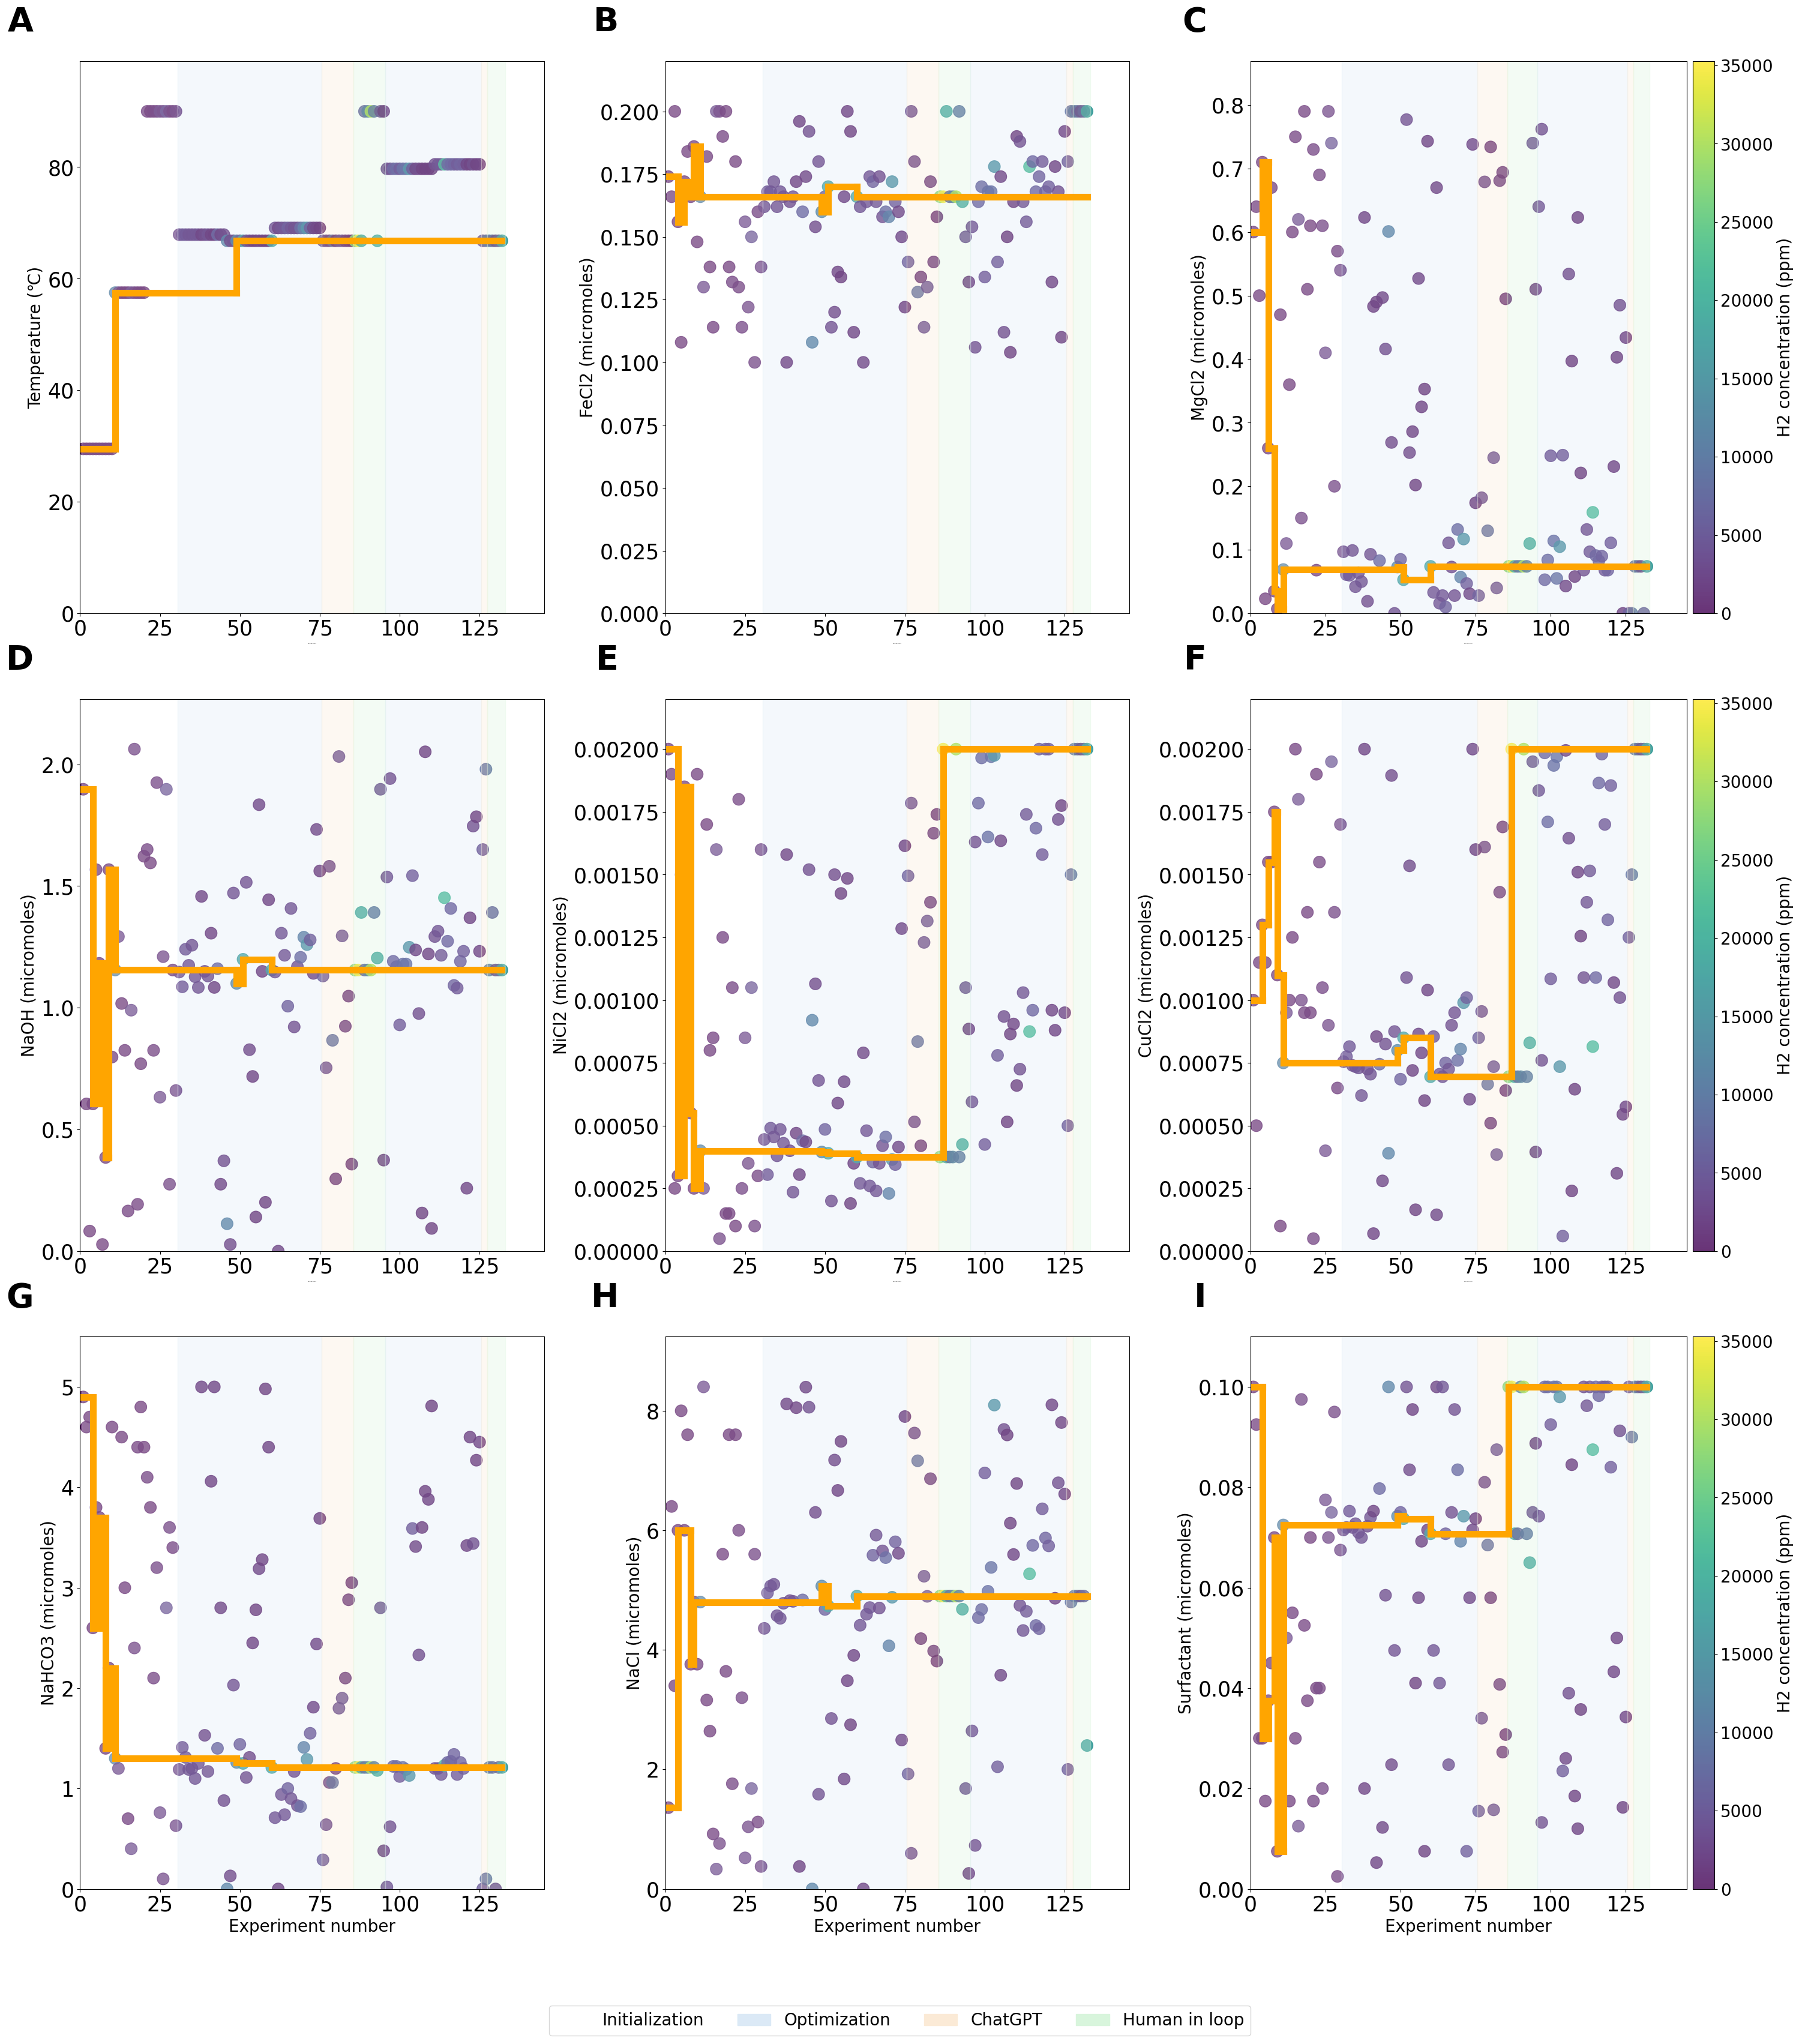

In [2]:
plot_combined_H2_parameters()